In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data

In [2]:
df = pd.read_csv('/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/combined_presentations_data_w3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

df.head(5)

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_vle_pre_w3,content_focus_pre_w3,collaborative_focus_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,date,id_assessment,is_banked,score,assessment_type,first_due_date,weight,week,submitted_first_assessment,relative_submission_date,submission_type
0,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,269,606.0,0.739274,0.260726,6,2.094273,1.812654,1.358621,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,3.0,1,2.0,Late
1,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,401.0,0.862843,0.137157,6,1.479023,1.414214,2.627691,18.0,1752.0,0.0,78.0,TMA,19.0,10.0,3.0,1,1.0,Late
2,23698,CCC,2014J,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass,-110.0,NaN,269,352.0,0.241477,0.068182,7,1.503976,2.160247,0.770281,21.0,24295.0,0.0,78.0,CMA,18.0,2.0,4.0,1,-3.0,Early
3,23798,BBB,2013J,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction,-27.0,NaN,268,115.0,0.495652,0.504348,7,2.031535,1.414214,3.236694,18.0,14996.0,0.0,90.0,TMA,19.0,5.0,3.0,1,1.0,Late
4,24734,AAA,2014J,F,South Region,Lower Than A Level,60-70%,0-35,0,60,N,Pass,-18.0,NaN,269,87.0,0.781609,0.218391,5,1.777750,0.894427,5.618846,23.0,1758.0,0.0,41.0,TMA,19.0,10.0,4.0,1,-4.0,Early


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'module_presentation_length', 'total_vle_pre_w3',
       'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 'date',
       'id_assessment', 'is_banked', 'score', 'assessment_type',
       'first_due_date', 'weight', 'week', 'submitted_first_assessment',
       'relative_submission_date', 'submission_type'],
      dtype='object')

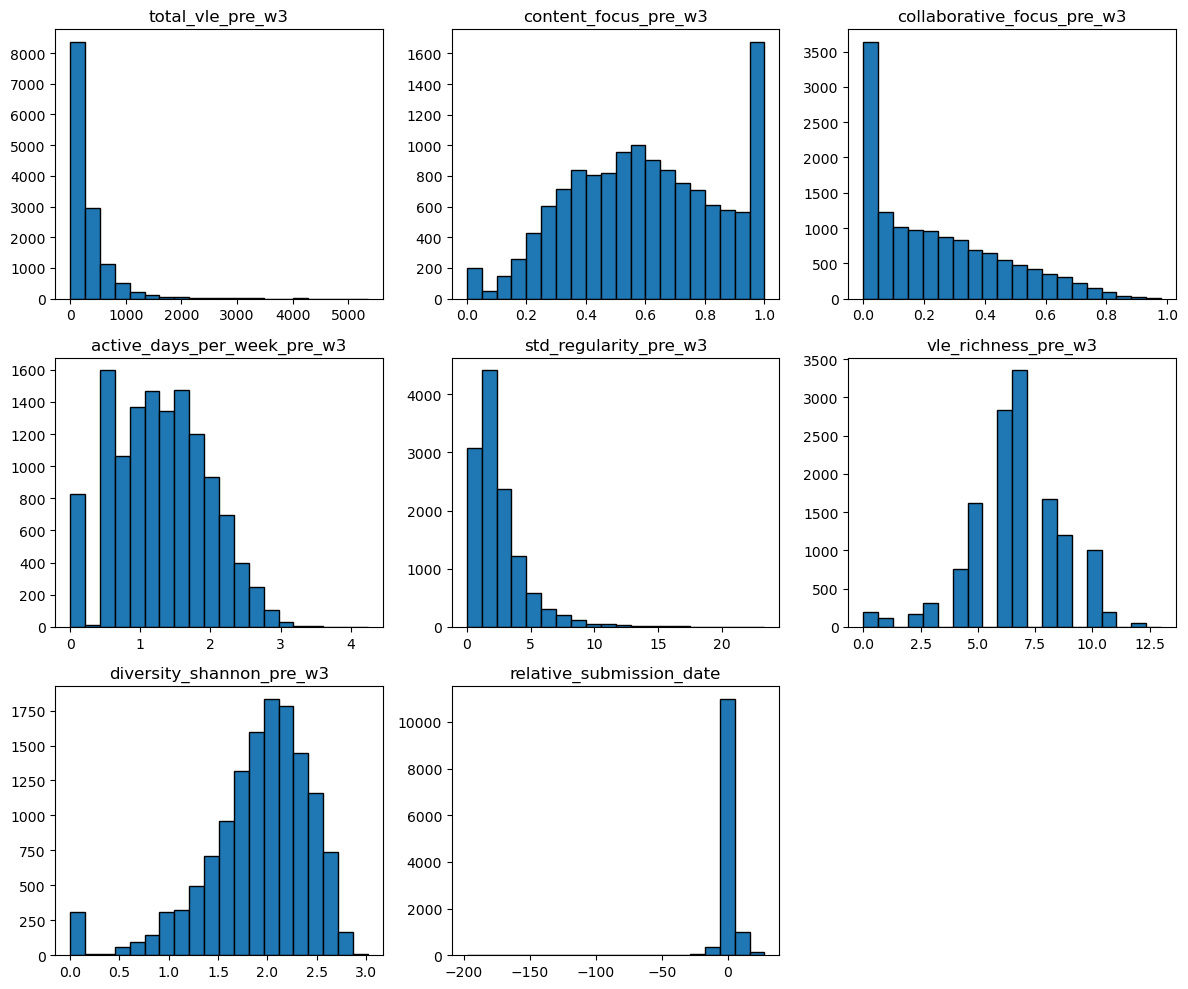

In [5]:
columns_to_display = ['total_vle_pre_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type']

# Select only the specified columns and create histograms
df[columns_to_display].hist(bins=20, figsize=(12, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

In [6]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


Distribution of final_result:

Counts:
final_result
Pass           6240
Fail           3018
Withdrawn      2676
Distinction    1537
Name: count, dtype: int64

Percentages:
final_result
Pass           46.321728
Fail           22.403682
Withdrawn      19.864895
Distinction    11.409695
Name: proportion, dtype: float64


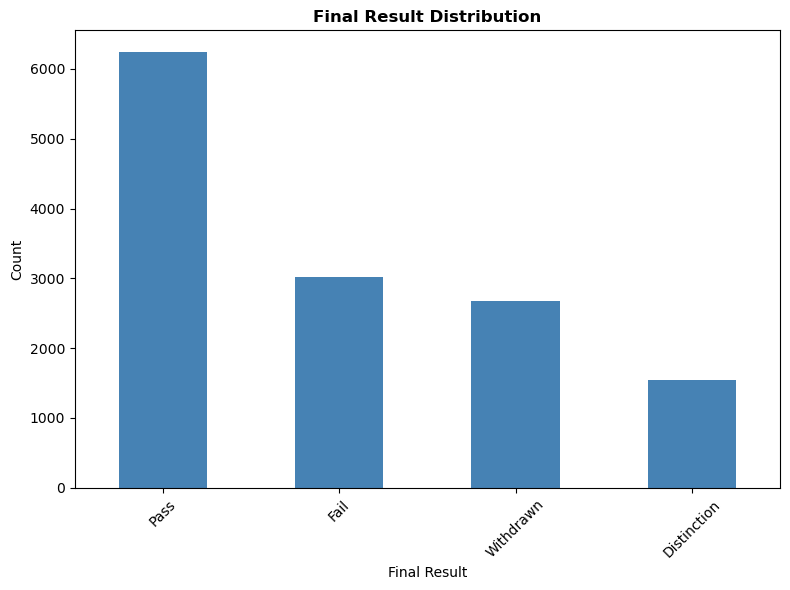


Total: 13471 students, 4 categories


In [7]:
# Examine distribution of final_result
print("Distribution of final_result:")
print("=" * 50)
print("\nCounts:")
print(df['final_result'].value_counts())
print("\nPercentages:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization
df['final_result'].value_counts().plot(kind='bar', color='steelblue', figsize=(8, 6))
plt.title('Final Result Distribution', fontweight='bold')
plt.xlabel('Final Result')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal: {len(df)} students, {df['final_result'].nunique()} categories")

## Data preprocessing

In [8]:
# Check sums of NA in each columns 
print(df.isna().sum())

columns_with_NA = df.columns[df.isna().any()].tolist()

id_student                         0
code_module                        0
code_presentation                  0
gender                             0
region                             0
highest_education                  0
imd_band                         503
age_band                           0
num_of_prev_attempts               0
studied_credits                    0
disability                         0
final_result                       0
date_registration                  0
date_unregistration            10833
module_presentation_length         0
total_vle_pre_w3                   0
content_focus_pre_w3               0
collaborative_focus_pre_w3         0
vle_richness_pre_w3                0
diversity_shannon_pre_w3           0
active_days_per_week_pre_w3      717
std_regularity_pre_w3            981
date                             917
id_assessment                      0
is_banked                        917
score                            933
assessment_type                    0
f

In [9]:
columns_with_NA

['imd_band',
 'date_unregistration',
 'active_days_per_week_pre_w3',
 'std_regularity_pre_w3',
 'date',
 'is_banked',
 'score',
 'week',
 'relative_submission_date']

In [10]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
# Not included: demographic features + relative_submission_date (because it would cause student who never submitted to get dropped)
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    'submission_type',
    'total_vle_pre_w3'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type
columns_to_fill_zeros = [
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3',
]
df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
df_model_clean = df_model.dropna() 


## Initial train-test split

In [11]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']


# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

In [12]:
# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {X["code_module"].value_counts(normalize = True).sort_index().values}")
print(f"Train:      {X["code_module"].loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {X["code_module"].loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57731423 0.42268577]
Train (1 = At-Risk):    [0.57720861 0.42279139]
Test (1 = At-Risk):     [0.57773655 0.42226345]

Module distribution:
------------------------------------------------------------
Original:   [0.05062727 0.39588746 0.24927622 0.08863485 0.2155742 ]
Train:      [0.05057535 0.39587973 0.24935041 0.08862287 0.21557164]
Test:       [0.05083488 0.39591837 0.24897959 0.08868275 0.21558442]


In [13]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Define models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost.sklearn import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
              'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
              'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

In [17]:
# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                     ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                     penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                     class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                               ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                   min_samples_split=50, min_samples_leaf=25,
                                                                   max_features='sqrt', max_samples=0.7,
                                                                   class_weight='balanced'))]),
    'Gradient Boosting': Pipeline([('preprocess', cat_processor),
                                   ('classify', GradientBoostingClassifier(random_state=SEED, n_estimators=100, 
                                                                          max_depth=3, learning_rate=0.1))]),
    'Extra Trees': Pipeline([('preprocess', cat_processor),
                            ('classify', ExtraTreesClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                             min_samples_split=50, min_samples_leaf=25,
                                                             max_features='sqrt', class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                         ('classify', XGBClassifier(random_state=SEED))])
}

In [18]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Train and compare models

In [19]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate

Note we have marked "Pass / Distinction" as 0 and "Fail / Withdrawn [after week 4]" as 1. With this encoding, "positive" classifications are "Fail / Withdrawn", and "negative" classifications are "Pass / Distinction" (in short: we are classifying whether a student is "at risk" or not.) Hence:
- the recall (also known as sensitivity) gives the proportion of at-risk students that the model correctly identifies;
- the specificity gives the proportion of not-at-risk students that the model correctly identifies;
- the precision gives the proportion of students flagged as at-risk by the model that actually fail / withdraw.
Maximizing recall corresponds to identifying as many at-risk students as possible; increasing precision corresponds to reducing the number of false positives. 

### Using `cross_validate`

In order to use `cross_validate` we stratify only by outcome, not by module.

In [20]:
# Train and evaluate with cross-validation
results = {}

for model in models:
    results[model] = cross_validate(models[model], X_train, y_train,
                                     scoring = ("roc_auc", "recall", "precision", "f1"), cv=5)

# Clean up results dictionary
summary_results = {}
for model in models:
    summary_results[model] = {'test_roc_auc' : np.mean(results[model]['test_roc_auc']),
                              'test_recall' : np.mean(results[model]['test_recall']),
                              'test_precision' : np.mean(results[model]['test_precision']),
                              'test_f1' : np.mean(results[model]['test_f1'])}
 

In [21]:
# Summarize the results in table form

summary_df = pd.DataFrame(summary_results).T
print(summary_df.to_string())

                       test_roc_auc  test_recall  test_precision   test_f1
Baseline (Stratified)      0.503068     0.434593        0.426265  0.430388
Logistic Regression        0.708626     0.613262        0.587863  0.600208
Random Forest              0.707370     0.582312        0.601117  0.591121
Gradient Boosting          0.704658     0.450617        0.649303  0.531808
Extra Trees                0.697670     0.626867        0.560327  0.591583
XGBoost                    0.672676     0.473443        0.590180  0.525200


### Manually using `StratifiedKFold`

This takes more code, but we can now stratify over module as well as module.
Note we first need to redo the train-test split so that we can further do stratified splits on the training test during cross-validation.

In [22]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']

## Keep extra copy of column in X_train for further use in cross-validation splits
X["stratify"] = stratify_column

# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Set X_train, y_train up for stratified splits during cross-validation
y_train = X_train["stratify"]
X_train.drop(["stratify"], axis=1, inplace=True)

In [23]:
from sklearn.model_selection import StratifiedKFold

# Train and evaluate with cross-validation
results = []
skf = StratifiedKFold(n_splits=5)

for model in models:
    auc, recall, precision, f1, overfit_gap = [], [], [], [], []
    for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_index]
        y_tt = y_train.iloc[train_index].apply(lambda x: int(x[0]))

        X_ho = X_train.iloc[test_index]
        y_ho = y_train.iloc[test_index].apply(lambda x: int(x[0]))   
        
        this_model = clone(models[model])
        this_model.fit(X_tt, y_tt)
    
        y_test_pred = this_model.predict(X_ho)
        y_train_pred = this_model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = this_model.predict_proba(X_ho)[:, 1]
            y_train_proba = this_model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        precision += [precision_score(y_ho, y_test_pred)]
        f1 += [f1_score(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]
 
    # Metrics averaged across all folds
    results.append({
        'Model': model,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Precision': np.mean(precision),
        'Test F1': np.mean(f1),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

In [24]:
results_df

,Model,Test ROC-AUC,Test Recall,Test Precision,Test F1,Overfitting Gap
1,Logistic Regression,0.709116,0.615021,0.588527,0.601393,0.000068
4,Extra Trees,0.698130,0.626218,0.561661,0.592026,0.003061
2,Random Forest,0.708000,0.579254,0.600723,0.589312,0.017654
3,Gradient Boosting,0.705600,0.457866,0.659953,0.540447,0.023687
5,XGBoost,0.675579,0.487056,0.602240,0.538482,0.247122
0,Baseline (Stratified),0.498123,0.428878,0.420667,0.424733,0.004060


In [28]:
# Display results
print("\nMODEL PERFORMANCE (Cross-Validation)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ BEST ROC-AUC: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%}")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP ROC-AUC: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Recall: {runner_up['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {runner_up['Test Precision']:.1%}")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Cross-Validation)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7091       0.6150          0.5885   0.6014           0.0001
          Extra Trees        0.6981       0.6262          0.5617   0.5920           0.0031
        Random Forest        0.7080       0.5793          0.6007   0.5893           0.0177
    Gradient Boosting        0.7056       0.4579          0.6600   0.5404           0.0237
              XGBoost        0.6756       0.4871          0.6022   0.5385           0.2471
Baseline (Stratified)        0.4981       0.4289          0.4207   0.4247           0.0041

KEY INSIGHTS

✓ BEST ROC-AUC: Logistic Regression
  • ROC-AUC: 0.709 (+0.211 vs baseline)
  • Recall: 61.5% of at-risk students identified
  • Precision: 58.9%
  • Overfitting: 0.000 ✓ Well-controlled

✓ RUNNER-UP ROC-AUC: Extra Trees
  • ROC-

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'Extra Trees': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    }
}

models_to_tune = ['Logistic Regression', 'Random Forest', 'Extra Trees']
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(clone(models[model_name]), param_grids[model_name], 
                        cv=5, scoring='recall', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train_numeric)
    print(f"Best params: {grid.best_params_}")
    print(f"Best recall: {grid.best_score_:.4f}")
    final_models[model_name] = grid.best_estimator_

tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']
tuned_et_model = final_models['Extra Trees']


Tuning Logistic Regression...
  Fold 1: Recall=0.6206, Precision=0.5799
  Fold 2: Recall=0.6414, Precision=0.5798
  Fold 3: Recall=0.6169, Precision=0.5776
  Fold 4: Recall=0.6059, Precision=0.5732
  Fold 5: Recall=0.6396, Precision=0.5745

Tuning Random Forest...
  Fold 1: Recall=0.6009, Precision=0.5969
  Fold 2: Recall=0.6075, Precision=0.5983
  Fold 3: Recall=0.6004, Precision=0.6071
  Fold 4: Recall=0.5818, Precision=0.5935
  Fold 5: Recall=0.6198, Precision=0.5887

RESULTS - LOGISTIC REGRESSION vs RANDOM FOREST
              Model          Recall       Precision              F1         ROC-AUC
Logistic Regression 0.6249 ± 0.0136 0.5770 ± 0.0027 0.5999 ± 0.0069 0.7040 ± 0.0065
      Random Forest 0.6021 ± 0.0123 0.5969 ± 0.0061 0.5994 ± 0.0062 0.7084 ± 0.0062

TRAINING FINAL MODELS

Logistic Regression:
Fitting 5 folds for each of 99 candidates, totalling 495 fits
  Best Parameters: {'classify__C': 0.01, 'classify__l1_ratio': 0.1}
  Best Recall: 0.6264

Random Forest:
Fitting 5 f

In [29]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'Extra Trees': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    }
}

models_to_tune = ['Logistic Regression', 'Random Forest', 'Extra Trees']
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(clone(models[model_name]), param_grids[model_name], 
                        cv=5, scoring='recall', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train_numeric)
    print(f"Best params: {grid.best_params_}")
    print(f"Best recall: {grid.best_score_:.4f}")
    final_models[model_name] = grid.best_estimator_

tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']
tuned_et_model = final_models['Extra Trees']


Tuning Logistic Regression...
Fitting 5 folds for each of 99 candidates, totalling 495 fits
Best params: {'classify__C': 0.01, 'classify__l1_ratio': 0.1}
Best recall: 0.6264

Tuning Random Forest...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 10, 'classify__min_samples_leaf': 50, 'classify__min_samples_split': 25, 'classify__n_estimators': 400}
Best recall: 0.6012

Tuning Extra Trees...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 4, 'classify__min_samples_leaf': 50, 'classify__min_samples_split': 25, 'classify__n_estimators': 100}
Best recall: 0.6383


## Threshold testing

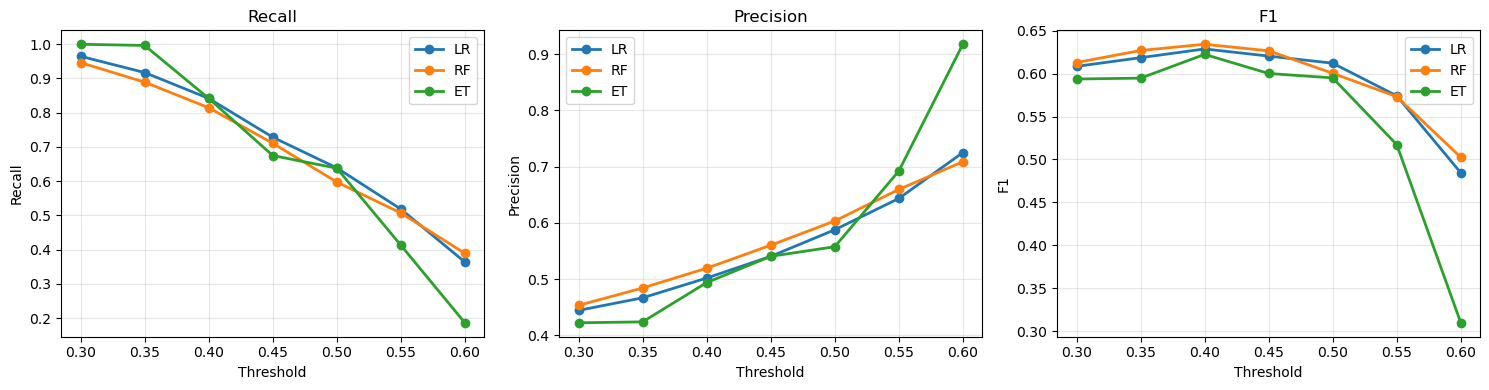

Model  Threshold   Recall  Precision       F1
   LR       0.30 0.964851   0.444355 0.608479
   RF       0.30 0.946397   0.453283 0.612977
   ET       0.30 1.000000   0.422263 0.593791
   LR       0.35 0.917399   0.466696 0.618667
   RF       0.35 0.889279   0.484211 0.627014
   ET       0.35 0.996485   0.423925 0.594807
   LR       0.40 0.841828   0.501833 0.628815
   RF       0.40 0.814587   0.519328 0.634280
   ET       0.40 0.841828   0.493814 0.622482
   LR       0.45 0.728471   0.540417 0.620509
   RF       0.45 0.710896   0.560249 0.626646
   ET       0.45 0.674868   0.540464 0.600234
   LR       0.50 0.638840   0.587712 0.612211
   RF       0.50 0.597540   0.603372 0.600442
   ET       0.50 0.637961   0.557604 0.595082
   LR       0.55 0.518453   0.643402 0.574209
   RF       0.55 0.507030   0.659429 0.573274
   ET       0.55 0.413005   0.692194 0.517336
   LR       0.60 0.363796   0.725044 0.484494
   RF       0.60 0.389279   0.708800 0.502552
   ET       0.60 0.186292   0.9177

In [31]:
# Threshold testing
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
results = []

y_test_numeric = y_test if y_test.dtype != 'object' else y_test.apply(lambda x: int(x[0]))

for thresh in thresholds:
    for name, model in [('LR', tuned_lr_model), ('RF', tuned_rf_model), ('ET', tuned_et_model)]:
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= thresh).astype(int)
        results.append({
            'Model': name,
            'Threshold': thresh,
            'Recall': recall_score(y_test_numeric, y_pred),
            'Precision': precision_score(y_test_numeric, y_pred),
            'F1': f1_score(y_test_numeric, y_pred)
        })

df_results = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, ax in zip(['Recall', 'Precision', 'F1'], axes):
    for model in ['LR', 'RF', 'ET']:
        data = df_results[df_results['Model'] == model]
        ax.plot(data['Threshold'], data[metric], 'o-', label=model, linewidth=2)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df_results.to_string(index=False))

## Feature importance analysis before running the model on the test holdout data


LR - Top 10 Features
                    Feature     Value
      submission_type_Never  1.001274
       submission_type_Late -0.639821
            code_module_FFF  0.514084
           total_vle_pre_w3 -0.256666
            code_module_BBB -0.138166
active_days_per_week_pre_w3 -0.128478
        vle_richness_pre_w3 -0.120604
            code_module_DDD  0.103285
            code_module_CCC  0.087350
 collaborative_focus_pre_w3 -0.084919

RF - Top 10 Features
                    Feature    Value
      submission_type_Never 0.207072
       submission_type_Late 0.196964
           total_vle_pre_w3 0.174111
 collaborative_focus_pre_w3 0.087331
      std_regularity_pre_w3 0.072516
active_days_per_week_pre_w3 0.059089
   diversity_shannon_pre_w3 0.054299
       content_focus_pre_w3 0.049672
        vle_richness_pre_w3 0.037175
            code_module_BBB 0.022959

ET - Top 10 Features
                    Feature    Value
      submission_type_Never 0.444102
       submission_type_Late 0.30608

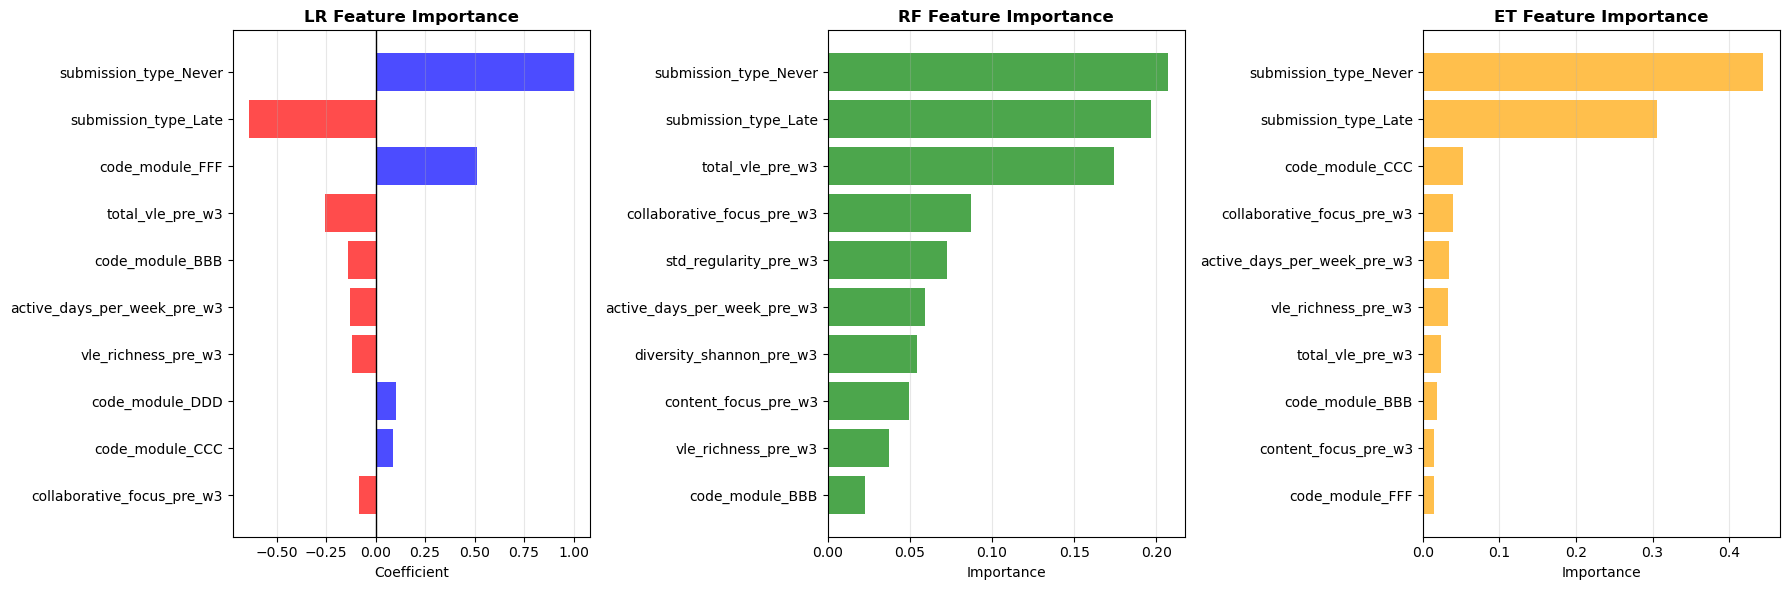

In [32]:
# Feature Importance Analysis
cat_features = list(tuned_lr_model.named_steps['preprocess'].named_transformers_['cat_encode'].get_feature_names_out(cat_cols))
all_features = scale_cols + cat_features

# Extract importances
importances = {
    'LR': pd.DataFrame({
        'Feature': all_features,
        'Value': tuned_lr_model.named_steps['classify'].coef_[0]
    }).sort_values('Value', key=abs, ascending=False),
    'RF': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_rf_model.named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False),
    'ET': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_et_model.named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False)
}

# Display top 10
for model, df in importances.items():
    print(f"\n{model} - Top 10 Features")
    print("=" * 60)
    print(df.head(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'LR': ['red' if v < 0 else 'blue' for v in importances['LR'].head(10)['Value']], 
          'RF': 'green', 'ET': 'orange'}

for ax, (model, df) in zip(axes, importances.items()):
    top = df.head(10)
    ax.barh(range(len(top)), top['Value'], color=colors[model], alpha=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Feature'])
    if model == 'LR':
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Coefficient' if model == 'LR' else 'Importance')
    ax.set_title(f'{model} Feature Importance', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Run model on test holdout data

TEST SET PERFORMANCE (Threshold = 0.4)
Model  ROC-AUC  Recall  Precision     F1
   LR   0.7176  0.8418     0.5018 0.6288
   RF   0.7232  0.8146     0.5193 0.6343
   ET   0.7020  0.8418     0.4938 0.6225


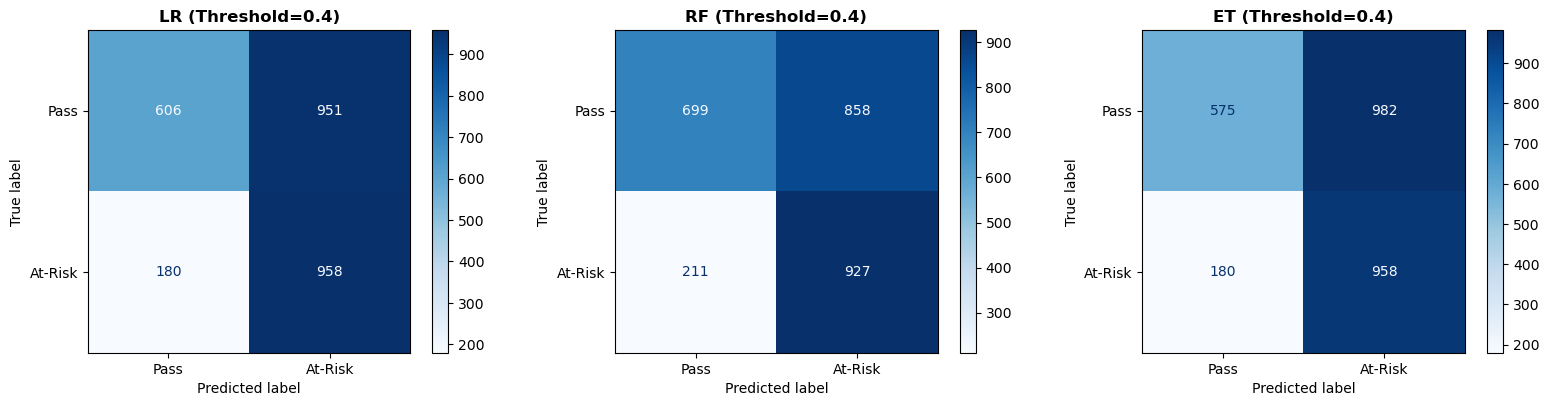

In [33]:
# Test Set Evaluation at Threshold 0.4
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_numeric = y_test if y_test.dtype != 'object' else y_test.apply(lambda x: int(x[0]))
models_eval = [('LR', tuned_lr_model), ('RF', tuned_rf_model), ('ET', tuned_et_model)]

# Calculate metrics
results = []
for name, model in models_eval:
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.4).astype(int)
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test_numeric, y_proba),
        'Recall': recall_score(y_test_numeric, y_pred),
        'Precision': precision_score(y_test_numeric, y_pred),
        'F1': f1_score(y_test_numeric, y_pred)
    })

print("TEST SET PERFORMANCE (Threshold = 0.4)")
print("=" * 60)
print(pd.DataFrame(results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, (name, model) in enumerate(models_eval):
    y_pred = (model.predict_proba(X_test)[:, 1] >= 0.4).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test_numeric, y_pred), 
                          display_labels=['Pass', 'At-Risk']).plot(cmap='Blues', ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{name} (Threshold=0.4)', fontweight='bold')
plt.tight_layout()
plt.show()